In [2]:
from google.colab import files
uploaded = files.upload()

Saving Preprocessed_Reviews_File.csv to Preprocessed_Reviews_File.csv


In [3]:
!pip install imbalanced-learn

Shape: (23465, 14)
Sentiment
Positive    18187
Neutral      2871
Negative     2407
Name: count, dtype: int64

TF-IDF Feature Matrix Shape: (23465, 5000)

Label Mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}
Class Distribution:
  Negative: 2407
  Neutral: 2871
  Positive: 18187

Train Set     : 16425 rows
Validation Set: 3520 rows
Test Set      : 3520 rows

   STEP 5: SMOTE — CLASS BALANCING

Class distribution BEFORE SMOTE:
  Negative: 1685
  Neutral: 2010
  Positive: 12730

Class distribution AFTER SMOTE:
  Negative: 12730
  Neutral: 12730
  Positive: 12730

Training samples before SMOTE: 16425
Training samples after SMOTE : 38190

Bias added after SMOTE. Final training shape: (38190, 5001)

   STEP 7A: ALPHA TUNING (SEQUENTIAL METHOD)
Alpha=0.001    Final Cost=0.693089
Alpha=0.01     Final Cost=0.654502
Alpha=0.1      Final Cost=0.633709
Alpha=1        Final Cost=0.491162
Alpha=3        Final Cost=0.382751
Alpha=5        Final Cost=0.338339
Alpha=7        Final Cost=0.313068
A

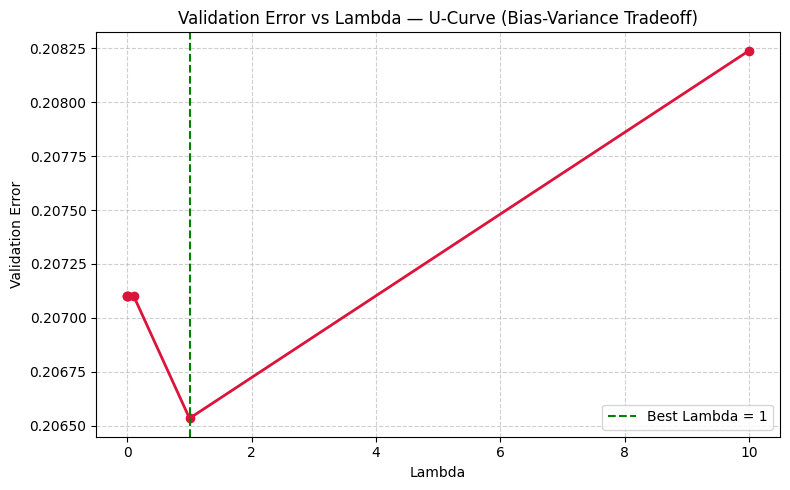


   STEP 8: BEST ITERATIONS (TOLERANCE METHOD)
  Max iterations (1500) reached

✔ Best Iterations     : 1500
  Avg Cost at convergence : 0.351771


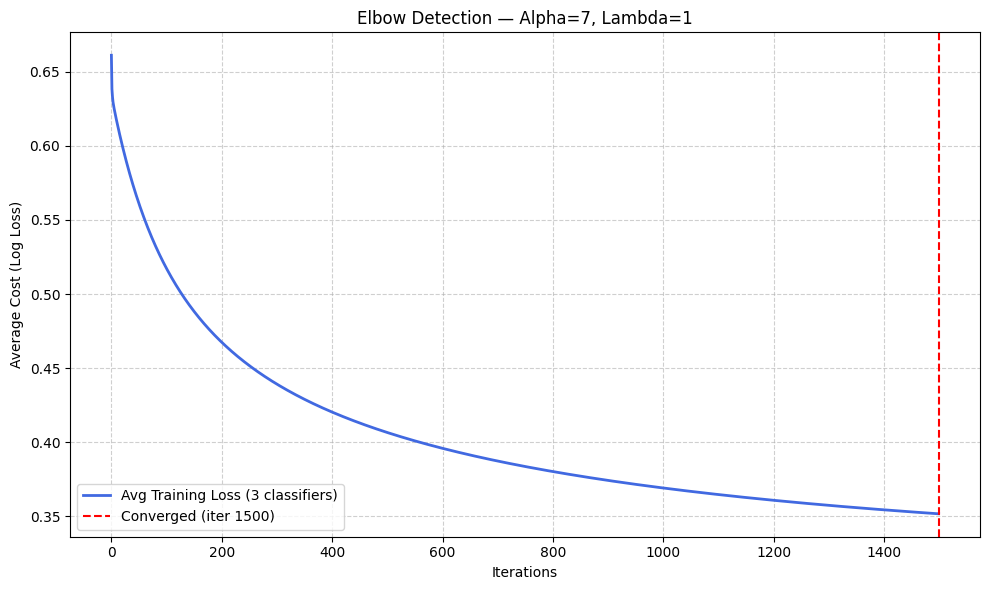


✔ Final Selected Hyperparameters:
  Alpha (Learning Rate)   : 7
  Lambda (Regularization) : 1
  Iterations              : 1500

   STEP 9: TRAINING FINAL MODEL (ONE-VS-REST)

Training classifier: Negative vs Rest
  Final Cost: 0.339662

Training classifier: Neutral vs Rest
  Final Cost: 0.431139

Training classifier: Positive vs Rest
  Final Cost: 0.284511

   STEP 10: VALIDATION SET RESULTS
Validation Accuracy: 79.49%

Classification Report:
               precision    recall  f1-score   support

    Negative       0.48      0.59      0.53       361
     Neutral       0.36      0.45      0.40       430
    Positive       0.94      0.88      0.91      2729

    accuracy                           0.79      3520
   macro avg       0.59      0.64      0.61      3520
weighted avg       0.83      0.79      0.81      3520



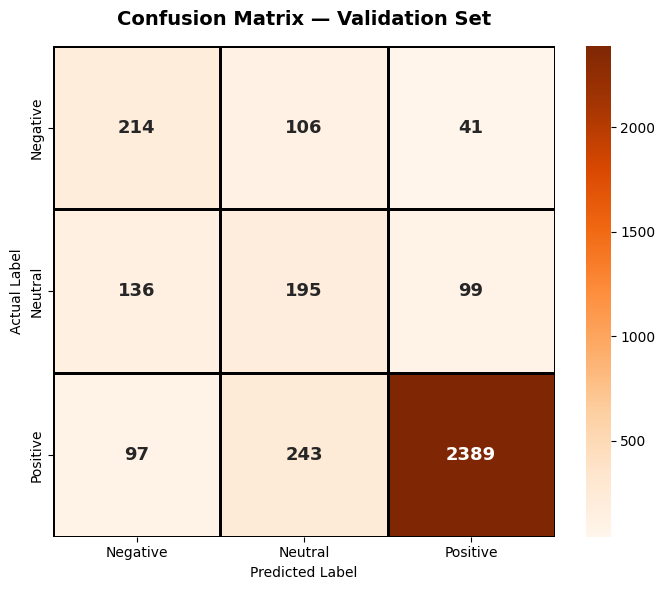


   STEP 11: TEST SET RESULTS (FINAL)
Test Accuracy : 79.60%
Precision     : 0.8236
Recall        : 0.7960
F1-Score      : 0.8079

Classification Report:
               precision    recall  f1-score   support

    Negative       0.48      0.59      0.53       361
     Neutral       0.35      0.44      0.39       431
    Positive       0.94      0.88      0.91      2728

    accuracy                           0.80      3520
   macro avg       0.59      0.64      0.61      3520
weighted avg       0.82      0.80      0.81      3520



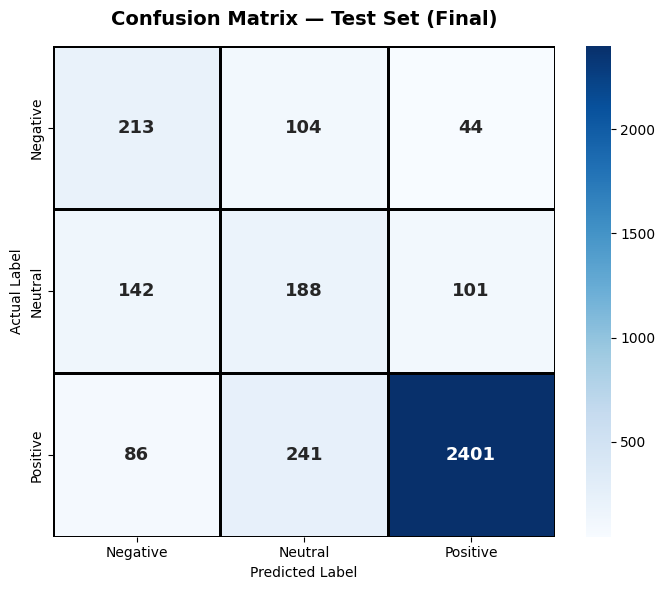

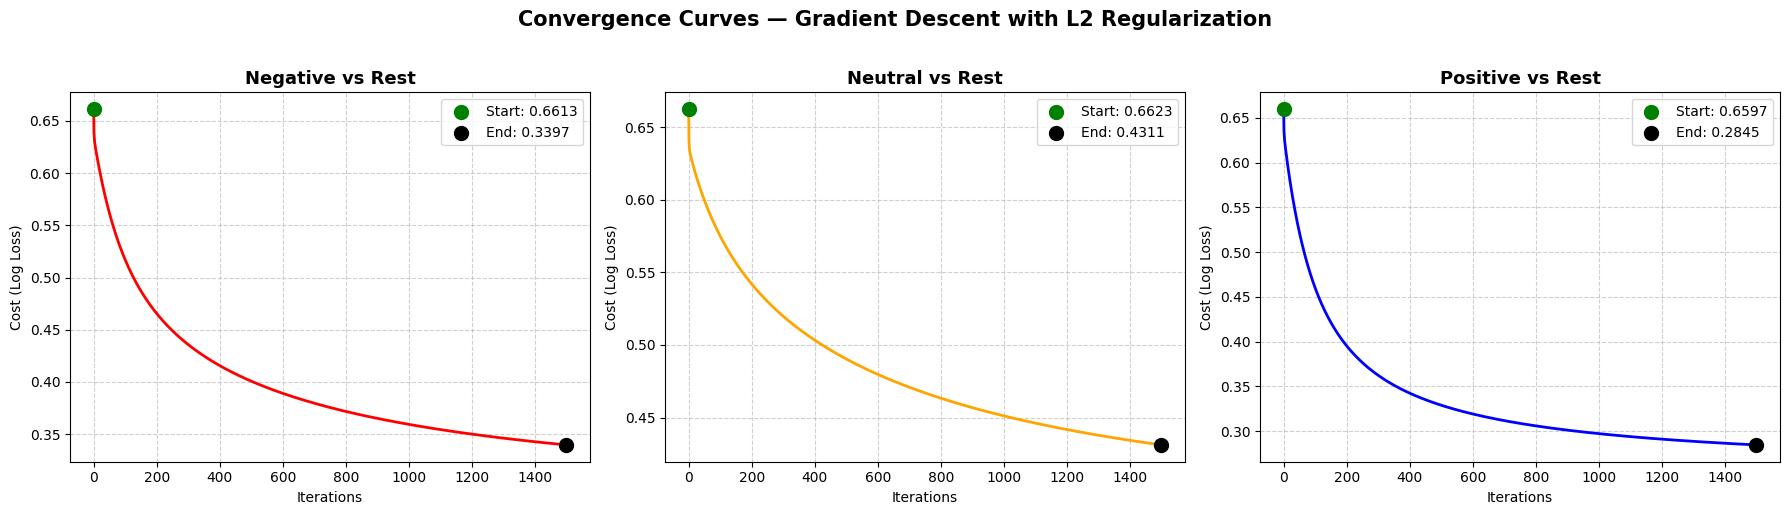


   CONVERGENCE SUMMARY

  Negative vs Rest:
    Starting Cost : 0.661292
    Final Cost    : 0.339662
    Cost Reduced  : 48.64%

  Neutral vs Rest:
    Starting Cost : 0.662320
    Final Cost    : 0.431139
    Cost Reduced  : 34.90%

  Positive vs Rest:
    Starting Cost : 0.659704
    Final Cost    : 0.284511
    Cost Reduced  : 56.87%

   COMPLETE ASSIGNMENT SUMMARY

  DATASET         : Women's Clothing E-Commerce Reviews
  TOTAL ROWS      : 23465
  TARGET          : Sentiment (Negative / Neutral / Positive)
  FEATURES        : TF-IDF (max_features=5000, ngram_range=(1,2))
  SPLIT           : 70% Train / 15% Validation / 15% Test
  ALGORITHM       : Logistic Regression (from scratch, One-vs-Rest)
  OPTIMIZER       : Gradient Descent
  REGULARIZATION  : L2 (Ridge)
  CLASS BALANCING : SMOTE (applied on raw features, before bias column)

  Training samples before SMOTE : 16425
  Training samples after SMOTE  : 38190

  Tuning method            : Validation accuracy, all 3 classifiers 

In [7]:
# ============================================================
# WOMEN'S CLOTHING — SENTIMENT ANALYSIS
# LOGISTIC REGRESSION FROM SCRATCH
# L2 REGULARIZATION + SMOTE  (CORRECTED VERSION)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_score,
                             recall_score, f1_score, accuracy_score,
                             classification_report)
from imblearn.over_sampling import SMOTE


# ============================================================
# STEP 1: LOAD PREPROCESSED DATA
# ============================================================
df = pd.read_csv("Preprocessed_Reviews_File.csv")
print("Shape:", df.shape)
print(df['Sentiment'].value_counts())


# ============================================================
# STEP 2: TF-IDF FEATURE GENERATION
# ============================================================
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X     = tfidf.fit_transform(df['Processed Text'])
y_raw = df['Sentiment']

print("\nTF-IDF Feature Matrix Shape:", X.shape)


# ============================================================
# STEP 3: ENCODE TARGET LABELS
# ============================================================
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
y         = y_raw.map(label_map).values

print("\nLabel Mapping:", label_map)
print("Class Distribution:")
for k, v in label_map.items():
    print(f"  {k}: {np.sum(y == v)}")


# ============================================================
# STEP 4: TRAIN / VALIDATION / TEST SPLIT (70/15/15)
# NOTE: bias column NOT added yet — SMOTE runs on raw
#       features first (FIX #3), bias is added after.
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTrain Set     : {X_train.shape[0]} rows")
print(f"Validation Set: {X_val.shape[0]} rows")
print(f"Test Set      : {X_test.shape[0]} rows")


# ============================================================
# STEP 5: SMOTE — CLASS IMBALANCE HANDLE KARNA
# Sirf training data pe, RAW features pe (bias se pehle) — FIX #3
# Validation aur test untouched
# ============================================================
print("\n" + "=" * 50)
print("   STEP 5: SMOTE — CLASS BALANCING")
print("=" * 50)

labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

print("\nClass distribution BEFORE SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {labels[u]}: {c}")

smote = SMOTE(random_state=42)
X_train_sm_raw, y_train_sm = smote.fit_resample(X_train.toarray(), y_train)
X_train_sm_raw = csr_matrix(X_train_sm_raw)

print("\nClass distribution AFTER SMOTE:")
u2, c2 = np.unique(y_train_sm, return_counts=True)
for u, c in zip(u2, c2):
    print(f"  {labels[u]}: {c}")

print(f"\nTraining samples before SMOTE: {X_train.shape[0]}")
print(f"Training samples after SMOTE : {X_train_sm_raw.shape[0]}")

# --- Now add the bias column (constant 1) to all three sets ---
ones_train = csr_matrix(np.ones((X_train_sm_raw.shape[0], 1)))
ones_val   = csr_matrix(np.ones((X_val.shape[0],           1)))
ones_test  = csr_matrix(np.ones((X_test.shape[0],          1)))

X_train_sm = hstack([ones_train, X_train_sm_raw]).tocsr()
X_val_b    = hstack([ones_val,   X_val          ]).tocsr()
X_test_b   = hstack([ones_test,  X_test         ]).tocsr()

print("\nBias added after SMOTE. Final training shape:", X_train_sm.shape)


# ============================================================
# STEP 6: LOGISTIC REGRESSION FROM SCRATCH
#         WITH L2 REGULARIZATION
# ============================================================

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def compute_cost(X, y, theta, lam=0):
    """
    Regularized Cost Function — Sir ki slide:
    J(theta) = -[1/m * sum(y*log(h) + (1-y)*log(1-h))]
               + lambda/2m * sum(theta_j^2)
    theta_0 (bias) regularize nahi hota — j=1 se shuru
    """
    m  = len(y)
    z  = X.dot(theta)
    h  = sigmoid(z)
    h  = np.clip(h, 1e-7, 1 - 1e-7)

    cross_entropy = (-1/m) * np.sum(
        y * np.log(h) + (1 - y) * np.log(1 - h)
    )
    l2_penalty = (lam / (2 * m)) * np.sum(theta[1:] ** 2)

    return cross_entropy + l2_penalty


def gradient_descent(X, y, theta, alpha, iterations, lam=0, track_cost=True):
    """
    Regularized Gradient Descent — Sir ki exact formula:
    theta_0 := theta_0 - alpha*(1/m)*sum(h-y)*x_0
    theta_j := theta_j(1 - alpha*lambda/m)
               - alpha*(1/m)*sum(h-y)*x_j   for j=1..n
    """
    m            = len(y)
    cost_history = []

    for i in range(iterations):
        z     = X.dot(theta)
        h     = sigmoid(z)
        error = h - y

        gradient    = (1/m) * X.T.dot(error)
        reg_term    = (lam / m) * theta.copy()
        reg_term[0] = 0

        theta = theta - alpha * (gradient + reg_term)
        if track_cost:
            cost_history.append(compute_cost(X, y, theta, lam))

    return theta, cost_history


def train_one_vs_rest(X, y, classes, alpha, iterations, lam, track_cost=True):
    """Trains one binary classifier per class, returns thetas + cost histories."""
    thetas_local = {}
    costs_local  = {}
    for c in classes:
        y_bin = (y == c).astype(int)
        theta0 = np.zeros(X.shape[1])
        theta_c, cost_c = gradient_descent(X, y_bin, theta0, alpha, iterations, lam, track_cost)
        thetas_local[c] = theta_c
        costs_local[c]  = cost_c
    return thetas_local, costs_local


def predict_multiclass(X, thetas, classes):
    probs = np.zeros((X.shape[0], len(classes)))
    for c in classes:
        probs[:, c] = sigmoid(X.dot(thetas[c]))
    return np.argmax(probs, axis=1)


classes     = [0, 1, 2]
class_names = ['Negative', 'Neutral', 'Positive']


# ============================================================
# STEP 7A: ALPHA TUNING — SEQUENTIAL, STOP-ON-INCREASE METHOD
# Lambda = 0 (baseline) rakh ke pehle best alpha dhoondo
# ============================================================
print("\n" + "=" * 70)
print("   STEP 7A: ALPHA TUNING (SEQUENTIAL METHOD)")
print("=" * 70)

alphas_to_try = [0.001, 0.01, 0.1, 1, 3, 5, 7, 10]
tuning_iterations = 500
tolerance = 1e-4

alpha_results = []
prev_cost = None
best_alpha = alphas_to_try[0]

for a in alphas_to_try:
    theta = np.zeros(X_train_sm.shape[1])
    y_bin = (y_train_sm == 2).astype(int)   # ek representative classifier se check
    cost_hist = []

    for i in range(tuning_iterations):
        z = X_train_sm.dot(theta)
        h = sigmoid(z)
        error = h - y_bin
        gradient = (1/len(y_bin)) * X_train_sm.T.dot(error)
        theta = theta - a * gradient
        cost_hist.append(compute_cost(X_train_sm, y_bin, theta, 0))

        if i > 0 and abs(cost_hist[-2] - cost_hist[-1]) < tolerance:
            break

    final_cost = cost_hist[-1]
    alpha_results.append({'alpha': a, 'final_cost': final_cost})
    print(f"Alpha={a:<8} Final Cost={final_cost:.6f}")

    if prev_cost is not None and final_cost > prev_cost:
        print(f"  -> Cost barh gaya, ruk rahe hain. Best alpha = {best_alpha}")
        break

    prev_cost = final_cost
    best_alpha = a   # abhi tak ka best, jab tak cost kam ho raha hai

print(f"\n✔ Best Alpha (sequential method): {best_alpha}")


# ============================================================
# STEP 7B: LAMBDA TUNING — U-CURVE, STOP-ON-INCREASE METHOD
# best_alpha fix rakh ke, lambda barhate jao jab tak
# validation error kam ho raha hai
# ============================================================
print("\n" + "=" * 70)
print("   STEP 7B: LAMBDA TUNING (VALIDATION ERROR U-CURVE)")
print("=" * 70)

lambdas_to_try = [0, 0.001, 0.01, 0.1, 1, 10]   # increasing order zaroori hai

lambda_results = []
prev_val_error = None
best_lambda = lambdas_to_try[0]

for lam in lambdas_to_try:
    thetas_cand, _ = train_one_vs_rest(
        X_train_sm, y_train_sm, classes, best_alpha, tuning_iterations, lam,
        track_cost=False
    )
    y_val_pred_cand = predict_multiclass(X_val_b, thetas_cand, classes)
    val_acc_cand = accuracy_score(y_val, y_val_pred_cand)
    val_error_cand = 1 - val_acc_cand

    lambda_results.append({'lambda': lam, 'val_error': val_error_cand})
    print(f"Lambda={lam:<8} Val Error={val_error_cand:.4f} (Val Acc={val_acc_cand*100:.2f}%)")

    if prev_val_error is not None and val_error_cand > prev_val_error:
        print(f"  -> Val error barh gaya, ruk rahe hain. Best lambda = {best_lambda}")
        break

    prev_val_error = val_error_cand
    best_lambda = lam

print(f"\n✔ Best Lambda (U-curve method): {best_lambda}")

# Plot — Validation Error vs Lambda curve
lam_vals  = [r['lambda'] for r in lambda_results]
err_vals  = [r['val_error'] for r in lambda_results]

plt.figure(figsize=(8, 5))
plt.plot(lam_vals, err_vals, marker='o', color='crimson', linewidth=2)
plt.axvline(best_lambda, color='green', linestyle='--',
            label=f'Best Lambda = {best_lambda}')
plt.xlabel("Lambda")
plt.ylabel("Validation Error")
plt.title("Validation Error vs Lambda — U-Curve (Bias-Variance Tradeoff)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('lambda_ucurve.png', dpi=150)
plt.show()

# ============================================================
# STEP 8: BEST ITERATIONS — TOLERANCE METHOD
# FIX #2 (partial): convergence is now tracked using the AVERAGE
# cost across all three one-vs-rest classifiers, not just class 2,
# so the chosen iteration count reflects the whole model.
# ============================================================
print("\n" + "=" * 50)
print("   STEP 8: BEST ITERATIONS (TOLERANCE METHOD)")
print("=" * 50)

lam = best_lambda

max_iter_long  = 1500
tolerance_iter = 1e-5

thetas_long = {c: np.zeros(X_train_sm.shape[1]) for c in classes}
avg_cost_history = []
best_iter_found  = max_iter_long

for i in range(max_iter_long):
    step_costs = []
    for c in classes:
        y_bin = (y_train_sm == c).astype(int)
        z     = X_train_sm.dot(thetas_long[c])
        h     = sigmoid(z)
        error = h - y_bin

        gradient    = (1/len(y_bin)) * X_train_sm.T.dot(error)
        reg_term    = (lam/len(y_bin)) * thetas_long[c].copy()
        reg_term[0] = 0

        thetas_long[c] = thetas_long[c] - best_alpha * (gradient + reg_term)
        step_costs.append(compute_cost(X_train_sm, y_bin, thetas_long[c], lam))

    avg_cost_history.append(np.mean(step_costs))

    if i > 0:
        improvement = abs(avg_cost_history[-2] - avg_cost_history[-1])
        if improvement < tolerance_iter:
            best_iter_found = i + 1
            print(f"  Converged at iteration: {best_iter_found}")
            print(f"  Improvement           : {improvement:.8f}")
            break

if best_iter_found == max_iter_long:
    print(f"  Max iterations ({max_iter_long}) reached")

print(f"\n✔ Best Iterations     : {best_iter_found}")
print(f"  Avg Cost at convergence : {avg_cost_history[-1]:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(avg_cost_history, color='royalblue', linewidth=2,
         label='Avg Training Loss (3 classifiers)')
plt.axvline(best_iter_found - 1, color='red', linestyle='--',
            label=f'Converged (iter {best_iter_found})')
plt.xlabel("Iterations")
plt.ylabel("Average Cost (Log Loss)")
plt.title(f"Elbow Detection — Alpha={best_alpha}, Lambda={lam}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('elbow_iteration_tuning.png', dpi=150)
plt.show()

best_iterations = best_iter_found
print(f"\n✔ Final Selected Hyperparameters:")
print(f"  Alpha (Learning Rate)   : {best_alpha}")
print(f"  Lambda (Regularization) : {best_lambda}")
print(f"  Iterations              : {best_iterations}")


# ============================================================
# STEP 9: TRAIN FINAL MODEL — ONE-VS-REST
# (full cost history tracked here for the report/plots)
# ============================================================
print("\n" + "=" * 50)
print("   STEP 9: TRAINING FINAL MODEL (ONE-VS-REST)")
print("=" * 50)

thetas         = {}
cost_histories = {}

for c in classes:
    print(f"\nTraining classifier: {class_names[c]} vs Rest")
    y_binary   = (y_train_sm == c).astype(int)
    theta_init = np.zeros(X_train_sm.shape[1])
    theta_c, cost_hist_c = gradient_descent(
        X_train_sm, y_binary, theta_init,
        best_alpha, best_iterations, lam, track_cost=True
    )
    thetas[c]         = theta_c
    cost_histories[c] = cost_hist_c
    print(f"  Final Cost: {cost_hist_c[-1]:.6f}")


# ============================================================
# STEP 10: VALIDATION SET EVALUATION
# ============================================================
y_val_pred   = predict_multiclass(X_val_b, thetas, classes)
val_accuracy = accuracy_score(y_val, y_val_pred) * 100

print("\n" + "=" * 50)
print("   STEP 10: VALIDATION SET RESULTS")
print("=" * 50)
print(f"Validation Accuracy: {val_accuracy:.2f}%")
print("\nClassification Report:\n",
      classification_report(y_val, y_val_pred, target_names=class_names))

cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black',
            annot_kws={"size": 13, "weight": "bold"})
plt.title('Confusion Matrix — Validation Set', fontsize=14,
          fontweight='bold', pad=15)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_val.png', dpi=150)
plt.show()


# ============================================================
# STEP 11: TEST SET EVALUATION
# ============================================================
y_test_pred   = predict_multiclass(X_test_b, thetas, classes)
test_accuracy = accuracy_score(y_test, y_test_pred) * 100
precision     = precision_score(y_test, y_test_pred, average='weighted')
recall        = recall_score(y_test, y_test_pred, average='weighted')
f1            = f1_score(y_test, y_test_pred, average='weighted')

print("\n" + "=" * 50)
print("   STEP 11: TEST SET RESULTS (FINAL)")
print("=" * 50)
print(f"Test Accuracy : {test_accuracy:.2f}%")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-Score      : {f1:.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, y_test_pred, target_names=class_names))

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black',
            annot_kws={"size": 13, "weight": "bold"})
plt.title('Confusion Matrix — Test Set (Final)', fontsize=14,
          fontweight='bold', pad=15)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=150)
plt.show()


# ============================================================
# STEP 12: CONVERGENCE CURVES — ALL 3 CLASSIFIERS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, c in enumerate(classes):
    axes[i].plot(cost_histories[c],
                 color=['red', 'orange', 'blue'][i], linewidth=2)
    axes[i].set_title(f'{class_names[c]} vs Rest',
                      fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Iterations')
    axes[i].set_ylabel('Cost (Log Loss)')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].scatter(0, cost_histories[c][0],
                    color='green', zorder=5, s=100,
                    label=f'Start: {cost_histories[c][0]:.4f}')
    axes[i].scatter(len(cost_histories[c])-1, cost_histories[c][-1],
                    color='black', zorder=5, s=100,
                    label=f'End: {cost_histories[c][-1]:.4f}')
    axes[i].legend(fontsize=10)

plt.suptitle(
    'Convergence Curves — Gradient Descent with L2 Regularization',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('convergence_proof.png', dpi=150)
plt.show()

print("\n" + "=" * 50)
print("   CONVERGENCE SUMMARY")
print("=" * 50)
for c in classes:
    start = cost_histories[c][0]
    end   = cost_histories[c][-1]
    drop  = ((start - end) / start) * 100
    print(f"\n  {class_names[c]} vs Rest:")
    print(f"    Starting Cost : {start:.6f}")
    print(f"    Final Cost    : {end:.6f}")
    print(f"    Cost Reduced  : {drop:.2f}%")


# ============================================================
# STEP 13: FINAL SUMMARY
# ============================================================
print("\n" + "=" * 50)
print("   COMPLETE ASSIGNMENT SUMMARY")
print("=" * 50)
print(f"""
  DATASET         : Women's Clothing E-Commerce Reviews
  TOTAL ROWS      : {df.shape[0]}
  TARGET          : Sentiment (Negative / Neutral / Positive)
  FEATURES        : TF-IDF (max_features=5000, ngram_range=(1,2))
  SPLIT           : 70% Train / 15% Validation / 15% Test
  ALGORITHM       : Logistic Regression (from scratch, One-vs-Rest)
  OPTIMIZER       : Gradient Descent
  REGULARIZATION  : L2 (Ridge)
  CLASS BALANCING : SMOTE (applied on raw features, before bias column)

  Training samples before SMOTE : {X_train.shape[0]}
  Training samples after SMOTE  : {X_train_sm.shape[0]}

  Tuning method            : Validation accuracy, all 3 classifiers per candidate
  Alpha (Learning Rate)    : {best_alpha}
  Lambda (Regularization)  : {best_lambda}
  Iterations               : {best_iterations}

  Validation Accuracy  : {val_accuracy:.2f}%
  Test Accuracy        : {test_accuracy:.2f}%
  Precision (weighted) : {precision:.4f}
  Recall (weighted)    : {recall:.4f}
  F1-Score (weighted)  : {f1:.4f}
""")
